In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from ipywidgets import interact

%config InlineBackend.figure_format = 'retina'

In [2]:
data = pd.read_csv('/Users/konansul/Downloads/titanic/train.csv', index_col = 'PassengerId')

In [3]:
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


In [5]:
data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [6]:
data.groupby('Sex')['Age'].mean()

Sex
female    27.915709
male      30.726645
Name: Age, dtype: float64

In [7]:
data.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [8]:
data.groupby('Survived')['Age'].mean()

Survived
0    30.626179
1    28.343690
Name: Age, dtype: float64

In [9]:
data['Age'].mean()

np.float64(29.69911764705882)

In [10]:
data['Sex'] = data['Sex'].map({'female': 0, 'male': 1})

In [11]:
data = data.drop(['Name', 'Ticket', 'Cabin'], axis = 1)

In [12]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,1,22.0,1,0,7.2500,S
2,1,1,0,38.0,1,0,71.2833,C
3,1,3,0,26.0,0,0,7.9250,S
4,1,1,0,35.0,1,0,53.1000,S
5,0,3,1,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,1,27.0,0,0,13.0000,S
888,1,1,0,19.0,0,0,30.0000,S
889,0,3,0,NaN,1,2,23.4500,S


In [13]:
data.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [14]:
data['Age'] = data.groupby('Sex')['Age'].transform(lambda x: x.fillna(x.mean())).round().astype(np.int64)

In [15]:
data[data['Embarked'].isna()]

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
62,1,1,0,38,0,0,80.0,NaN
830,1,1,0,62,0,0,80.0,NaN


In [16]:
data = data.drop([62, 830], axis = 0)

In [17]:
data

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,
1,0,3,1,22,1,0,7.2500,S
2,1,1,0,38,1,0,71.2833,C
3,1,3,0,26,0,0,7.9250,S
4,1,1,0,35,1,0,53.1000,S
5,0,3,1,35,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
887,0,2,1,27,0,0,13.0000,S
888,1,1,0,19,0,0,30.0000,S
889,0,3,0,28,1,2,23.4500,S


In [18]:
data.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

<Axes: >

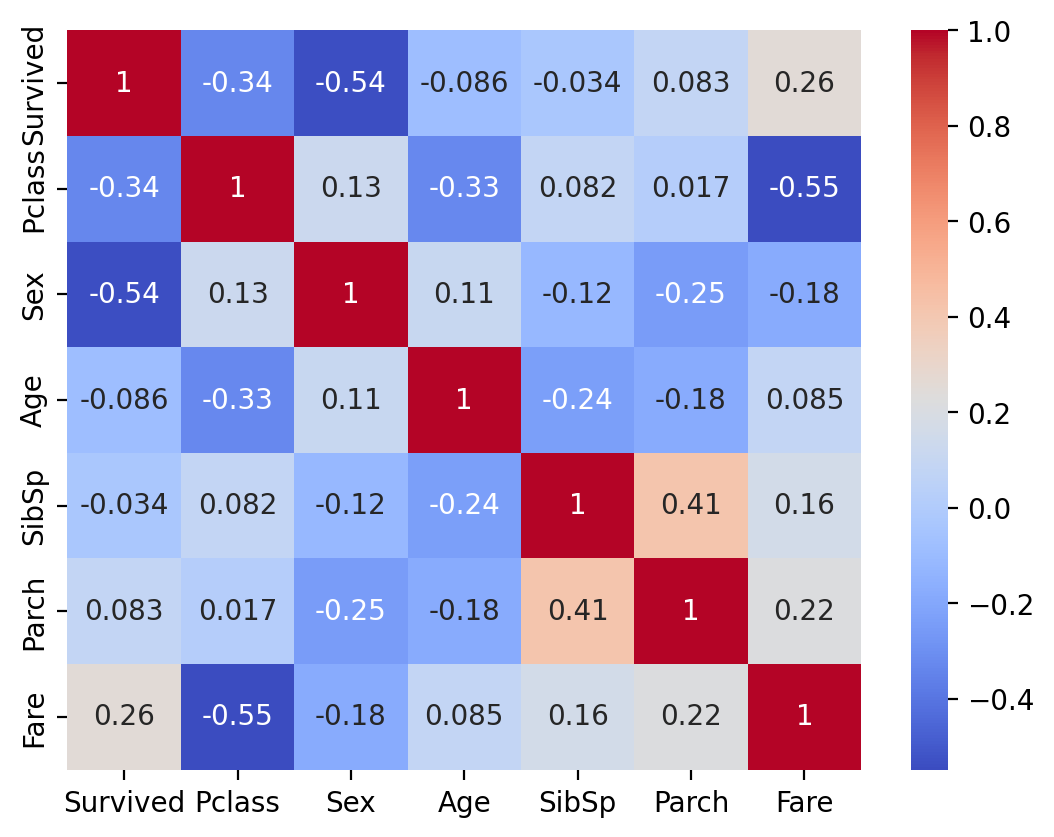

In [19]:
sns.heatmap(data.corr(numeric_only = True), annot = True, cmap = 'coolwarm')

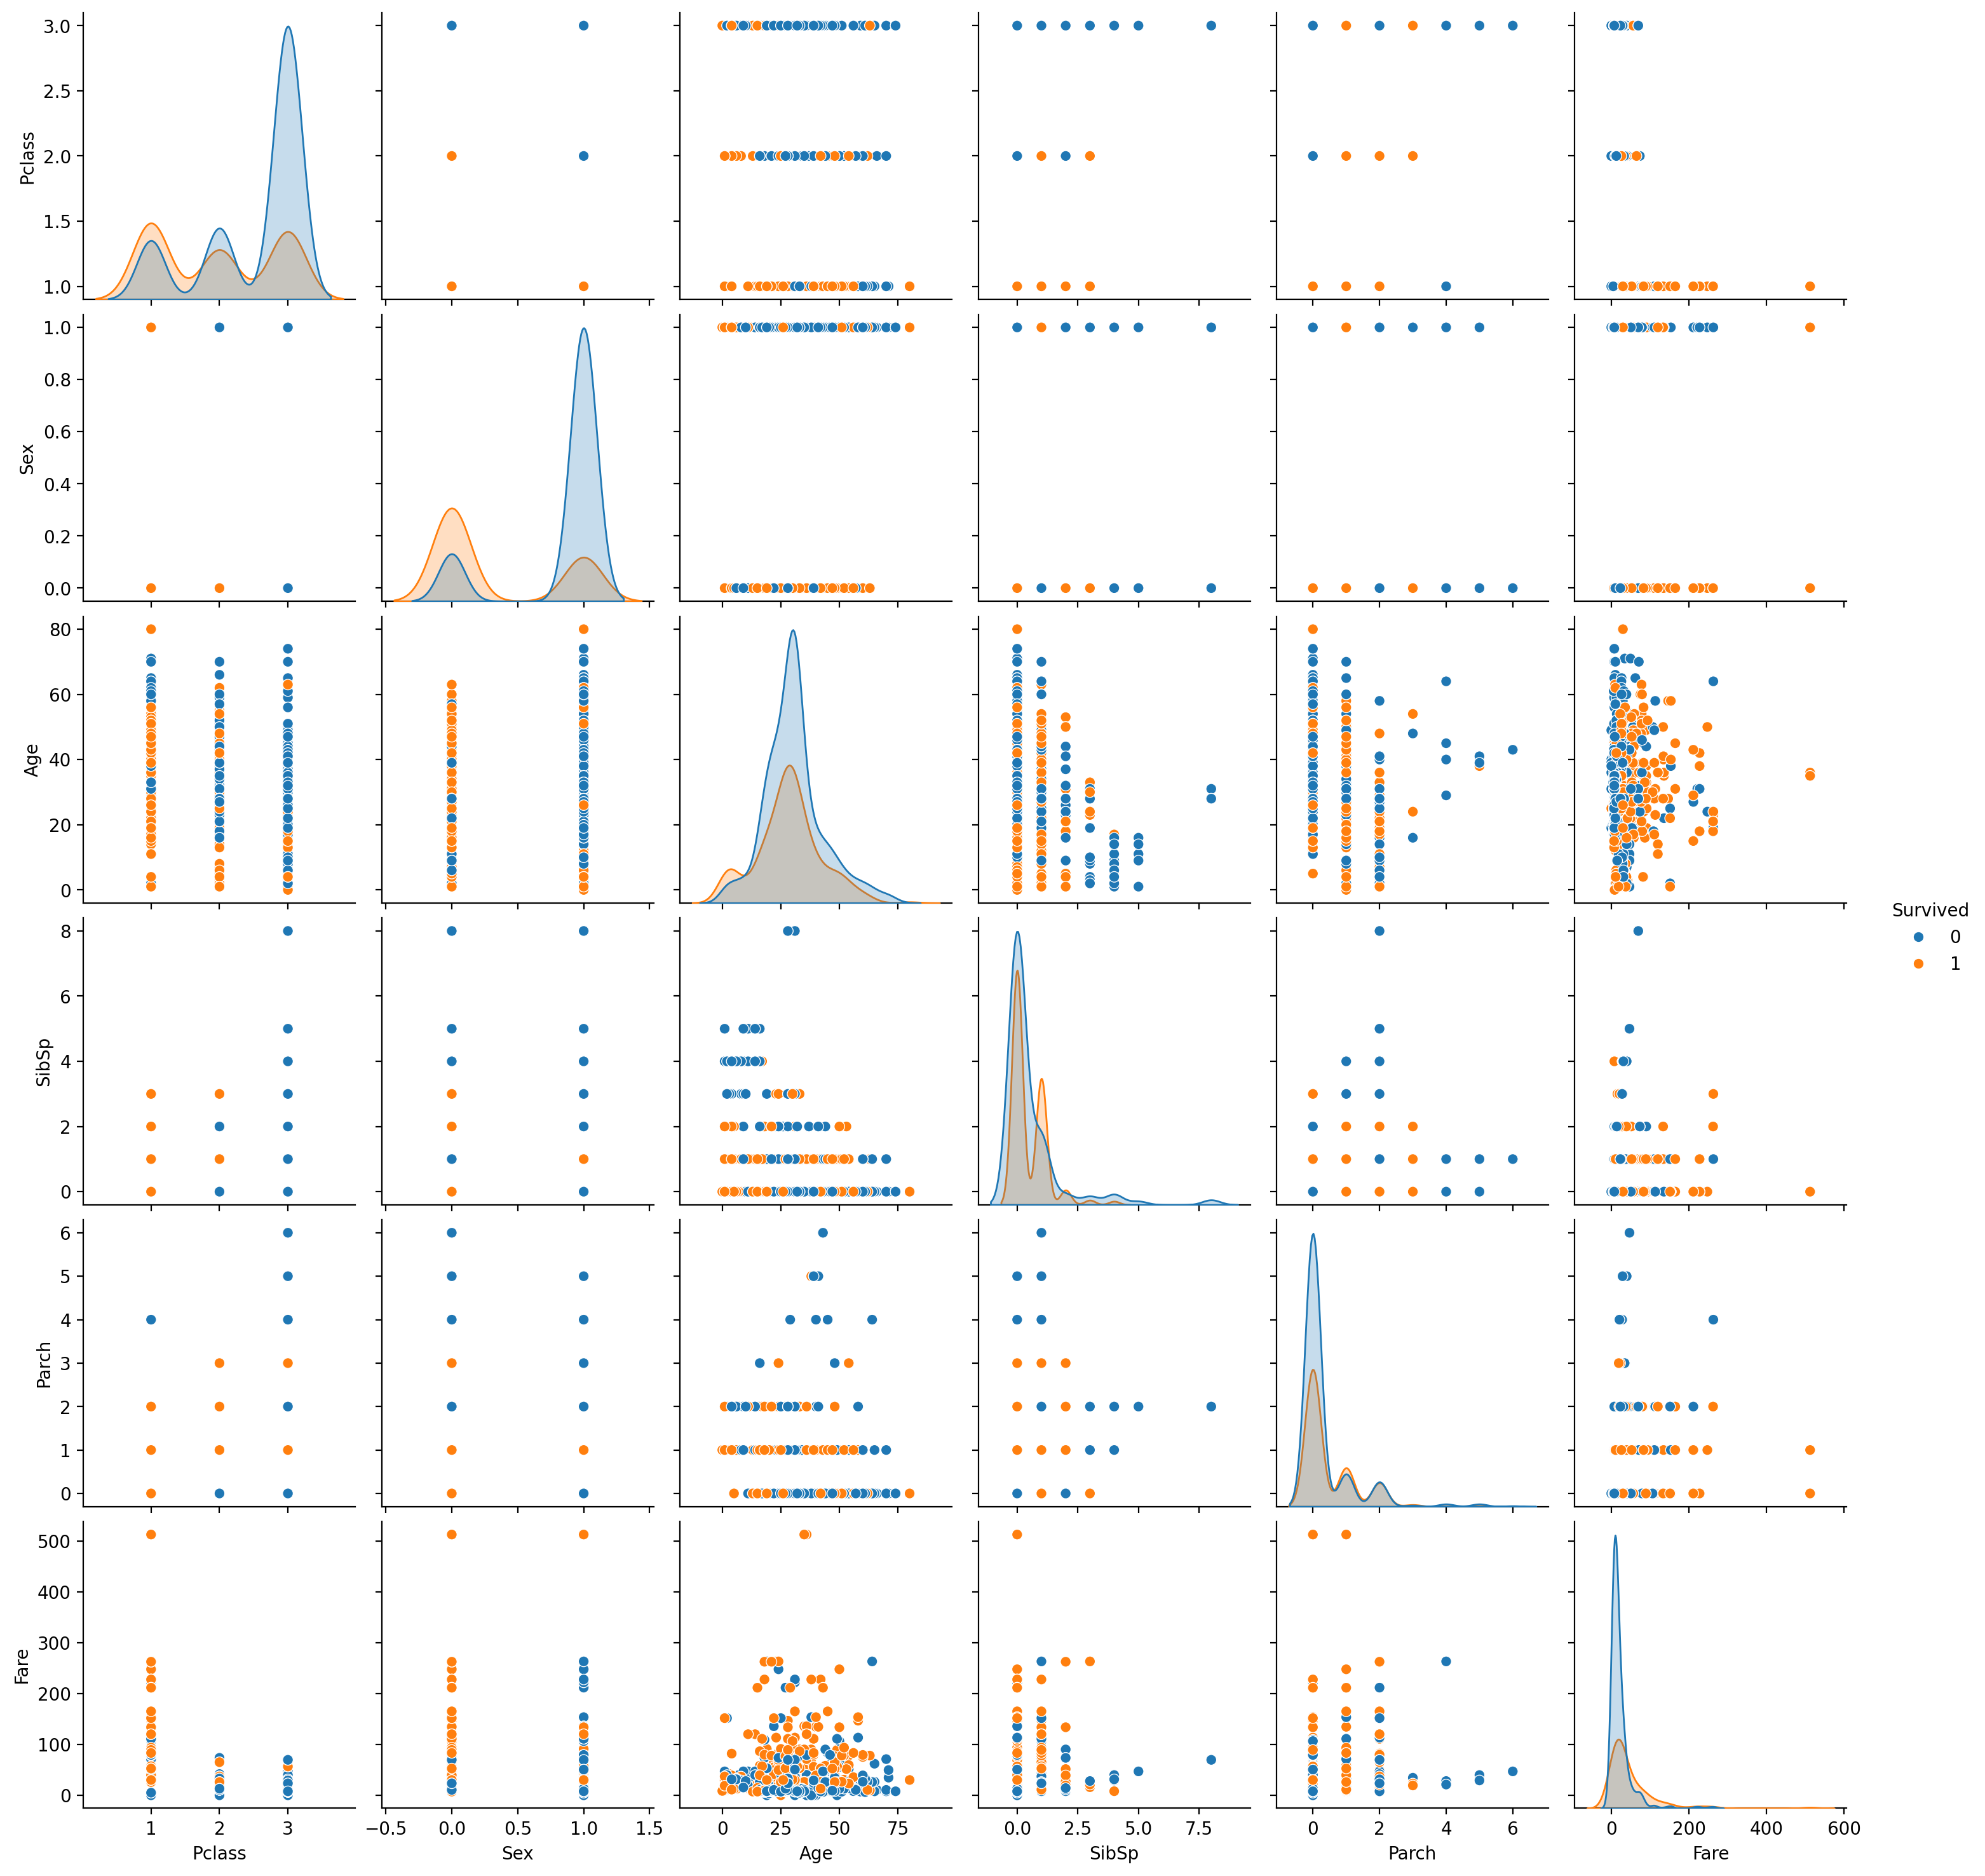

In [20]:
sns.pairplot(data, hue = 'Survived')

In [21]:
data['Pclass'].value_counts()

Pclass
3    491
1    214
2    184
Name: count, dtype: int64

In [22]:
data['Pclass'] = data['Pclass'].map({1 : 'first', 2: 'second', 3: 'third'})

In [23]:
data = pd.get_dummies(data, drop_first = True).astype(int)

In [24]:
data

,Survived,Sex,Age,SibSp,Parch,Fare,Pclass_second,Pclass_third,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,,
1,0,1,22,1,0,7,0,1,0,1
2,1,0,38,1,0,71,0,0,0,0
3,1,0,26,0,0,7,0,1,0,1
4,1,0,35,1,0,53,0,0,0,1
5,0,1,35,0,0,8,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...
887,0,1,27,0,0,13,1,0,0,1
888,1,0,19,0,0,30,0,0,0,1
889,0,0,28,1,2,23,0,1,0,1


In [25]:
def plot_metrics(model, x_test, y_test):
    y_pred = model.predict(x_test)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_estimator(model, x_test, y_test, ax=axes[0], cmap = 'Blues')
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=axes[1])
    PrecisionRecallDisplay.from_estimator(model, x_test, y_test, ax=axes[2])
    print(classification_report(y_test, y_pred))
    axes[0].set_title("Confusion Matrix")
    axes[1].set_title("ROC Curve")
    axes[2].set_title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

In [26]:
X = data.drop('Survived', axis = 1)

In [27]:
y = data['Survived']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 101)

In [29]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

/Users/konansul/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


              precision    recall  f1-score   support

           0       0.82      0.91      0.86       163
           1       0.84      0.68      0.75       104

    accuracy                           0.82       267
   macro avg       0.83      0.80      0.81       267
weighted avg       0.83      0.82      0.82       267



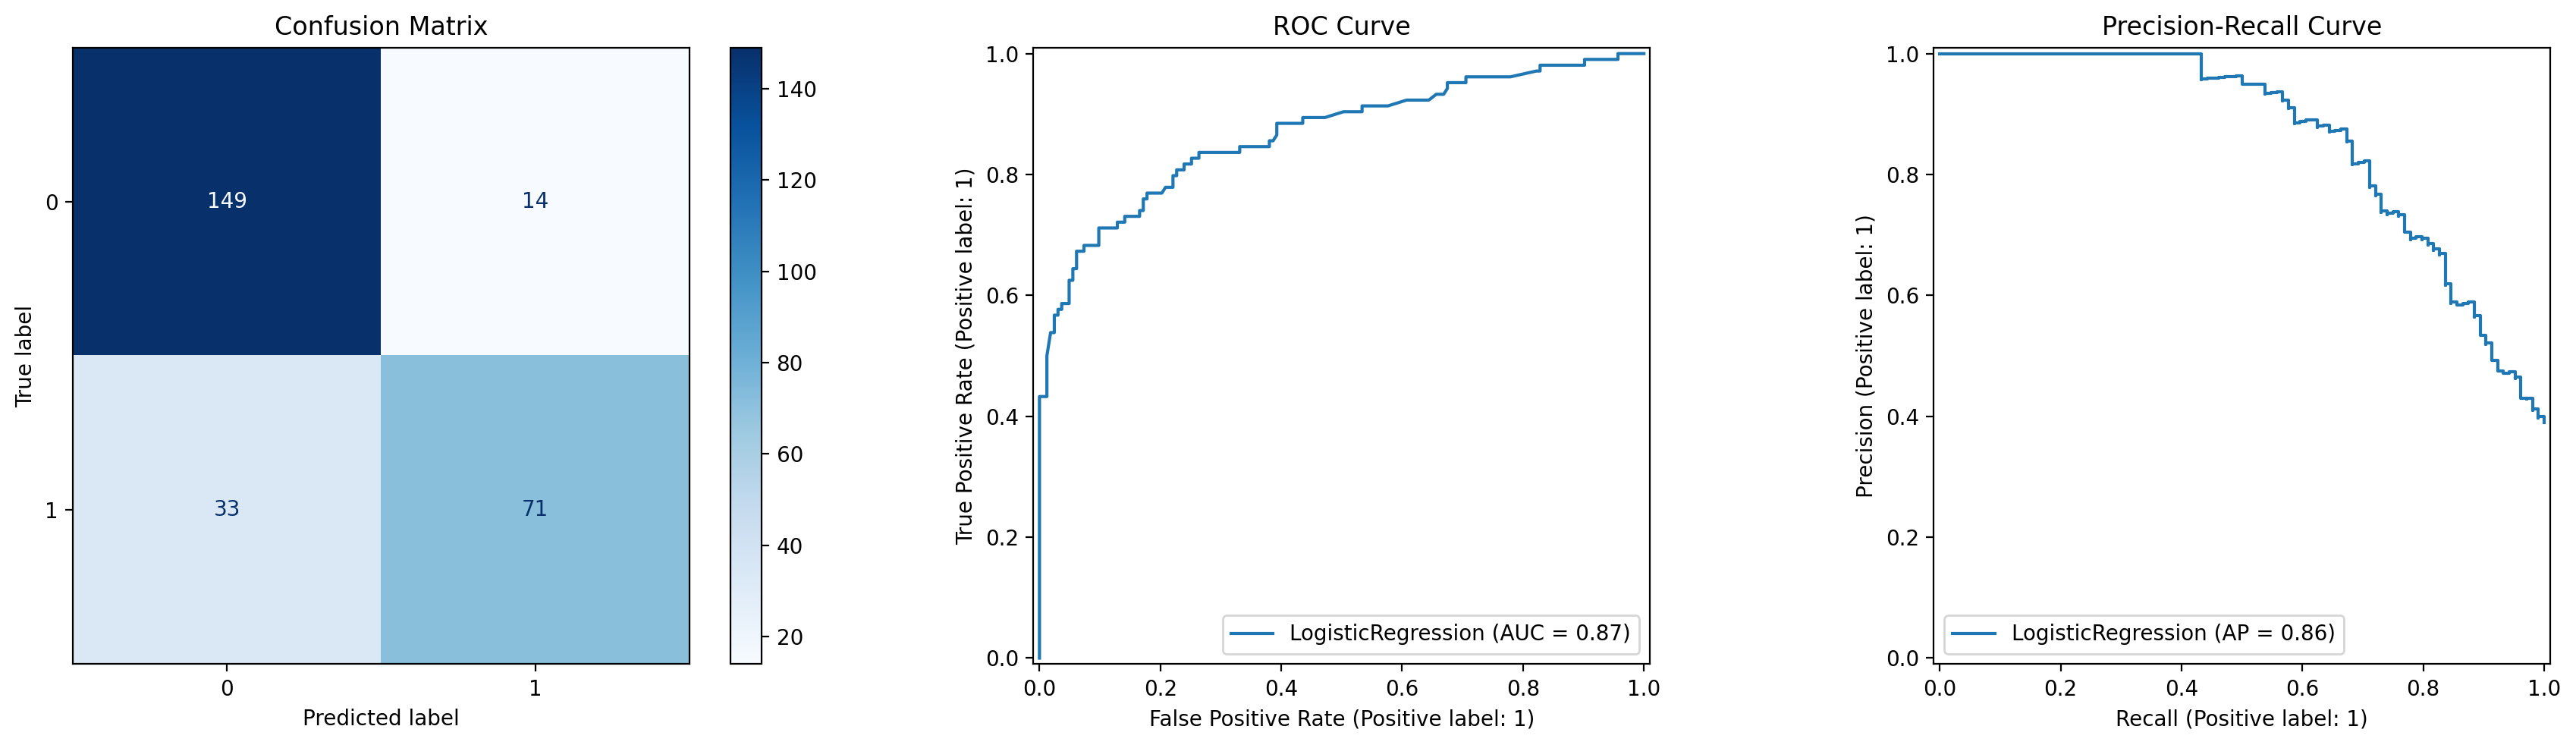

In [30]:
plot_metrics(log_model, X_test, y_test)

In [31]:
knn_model = KNeighborsClassifier(n_neighbors = 3)
knn_model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


              precision    recall  f1-score   support

           0       0.74      0.74      0.74       163
           1       0.59      0.60      0.59       104

    accuracy                           0.68       267
   macro avg       0.67      0.67      0.67       267
weighted avg       0.68      0.68      0.68       267



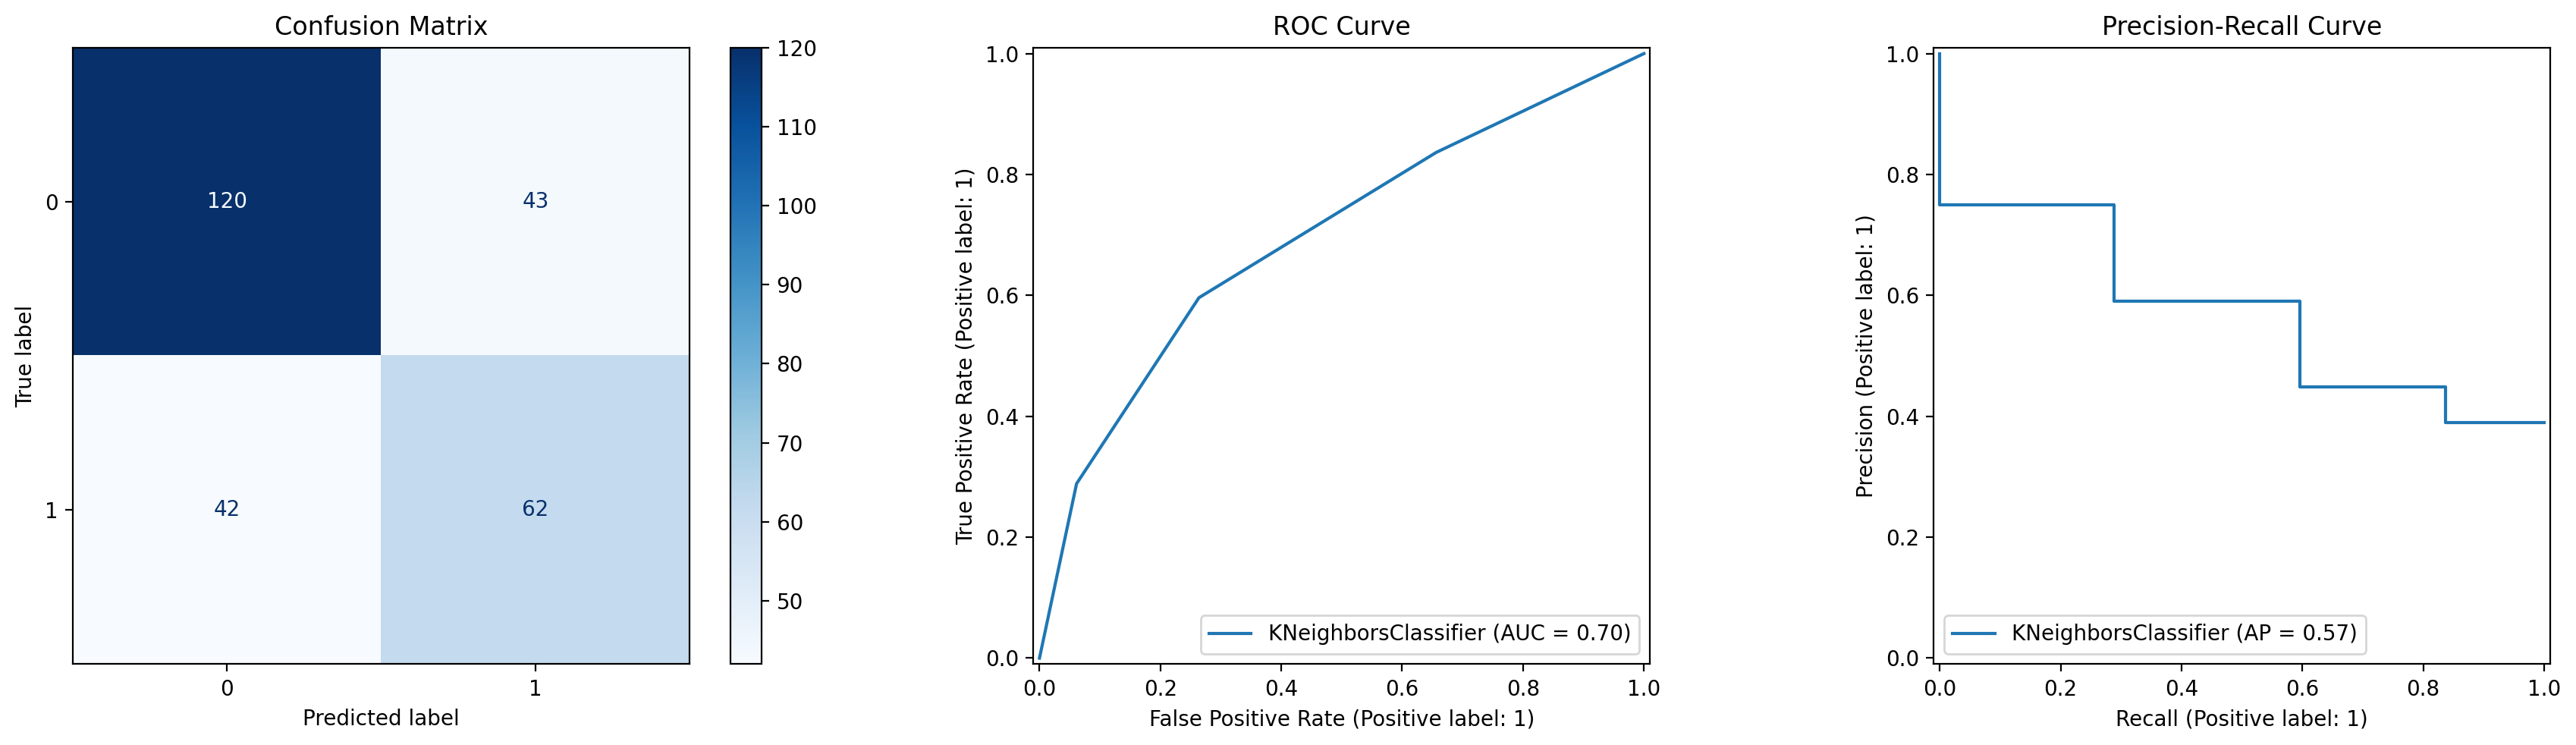

In [32]:
plot_metrics(knn_model, X_test, y_test)

In [33]:
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


              precision    recall  f1-score   support

           0       0.80      0.85      0.82       163
           1       0.73      0.66      0.70       104

    accuracy                           0.78       267
   macro avg       0.77      0.76      0.76       267
weighted avg       0.77      0.78      0.77       267



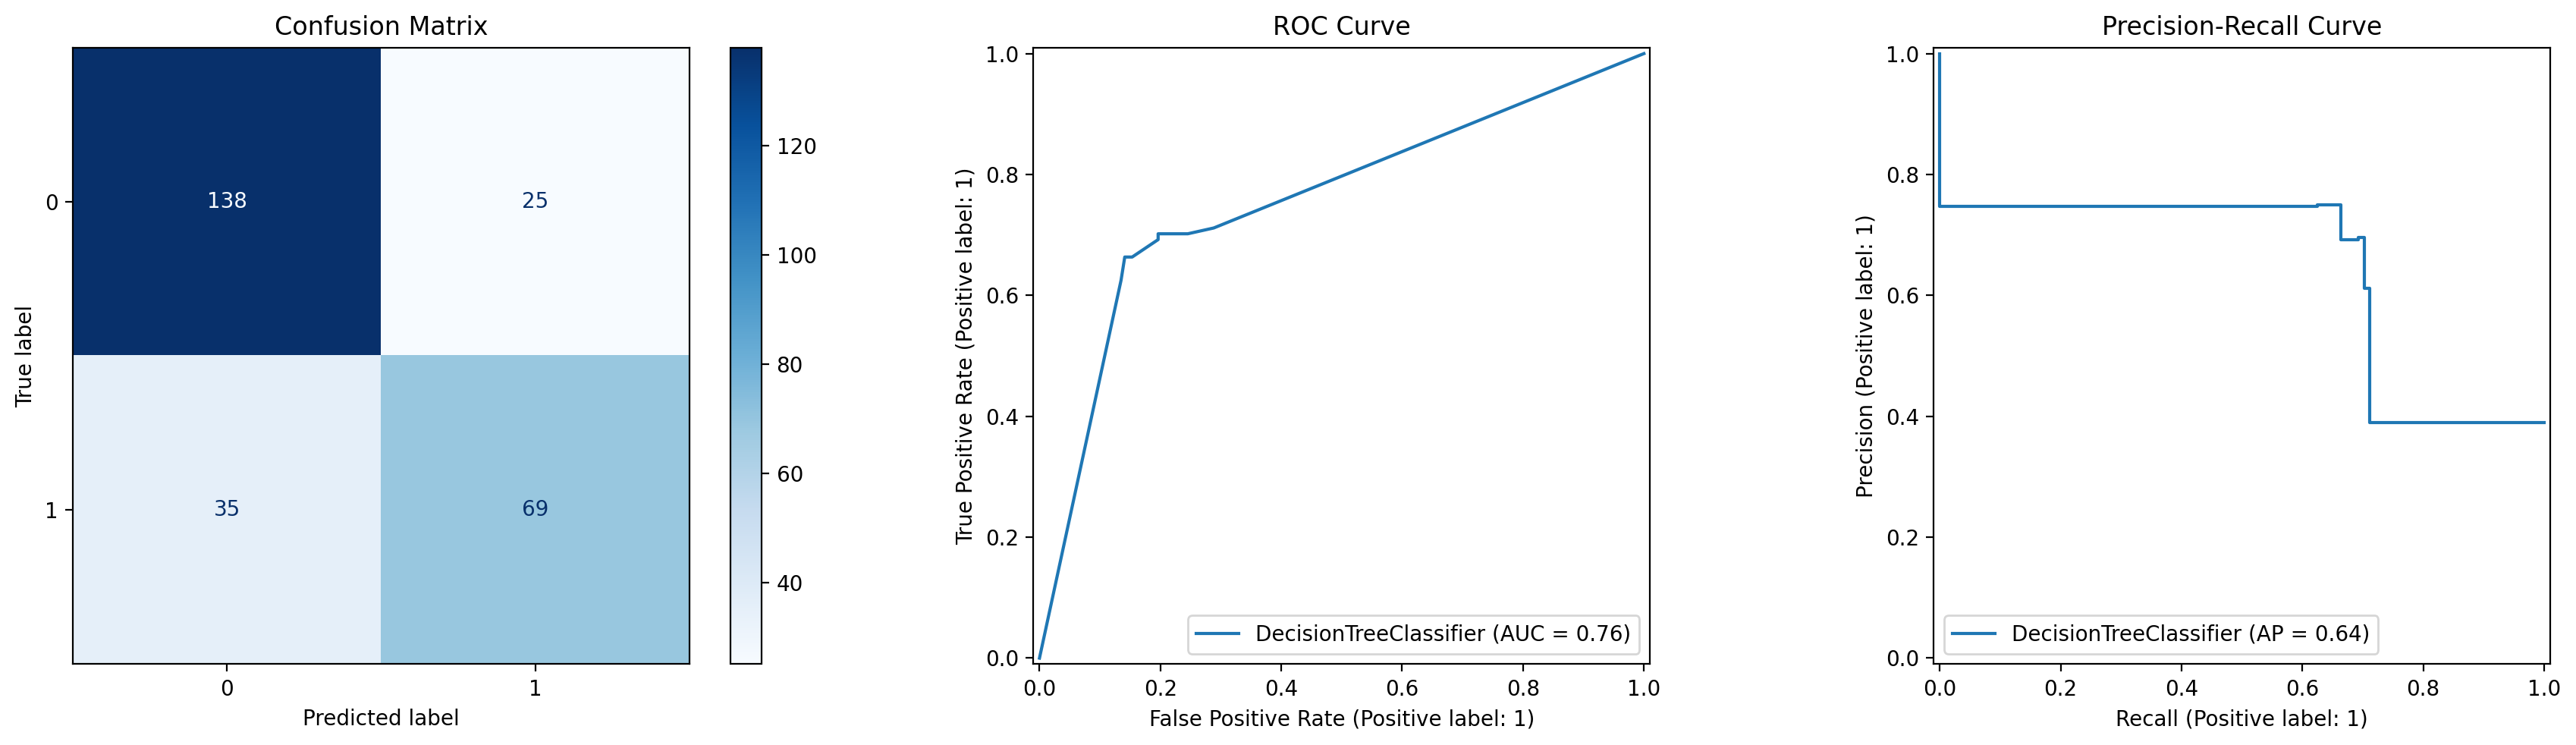

In [34]:
plot_metrics(tree_model, X_test, y_test)

In [35]:
finalmodel = LogisticRegression()
finalmodel.fit(X, y)

/Users/konansul/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [67]:
test = pd.read_csv('/Users/konansul/Downloads/titanic/test.csv', index_col = 'PassengerId')

In [68]:
test

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...
1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S


In [69]:
test.isnull().sum()

Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
dtype: int64

In [70]:
test[test['Fare'].isna()]

,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,
1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [71]:
test['Fare'] = test['Fare'].fillna(test['Fare'].mean())

In [72]:
test.isnull().sum()

Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       327
Embarked      0
dtype: int64

In [73]:
test['Sex'] = test['Sex'].map({'female': 0, 'male': 1})
test = test.drop(['Name', 'Ticket', 'Cabin'], axis=1)
test['Age'] = test.groupby('Sex')['Age'].transform(lambda x: x.fillna(x.mean())).round().astype(np.int64)
test['Pclass'] = test['Pclass'].map({1: 'first', 2: 'second', 3: 'third'})
test = pd.get_dummies(test, drop_first=True).astype(int)

In [74]:
test

,Sex,Age,SibSp,Parch,Fare,Pclass_second,Pclass_third,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,
892,1,34,0,0,7,0,1,1,0
893,0,47,1,0,7,0,1,0,1
894,1,62,0,0,9,1,0,1,0
895,1,27,0,0,8,0,1,0,1
896,0,22,1,1,12,0,1,0,1
...,...,...,...,...,...,...,...,...,...
1305,1,30,0,0,8,0,1,0,1
1306,0,39,0,0,108,0,0,0,0
1307,1,38,0,0,7,0,1,0,1


In [75]:
test.index

Index([ 892,  893,  894,  895,  896,  897,  898,  899,  900,  901,
       ...
       1300, 1301, 1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309],
      dtype='int64', name='PassengerId', length=418)

In [45]:
predictions = finalmodel.predict(test)

In [46]:
submission = pd.DataFrame({
    'PassengerId': test.index,
    'Survived': predictions
})

submission.to_csv('submission.csv', index=False)

In [48]:
forest_model = RandomForestClassifier(criterion = 'entropy')
forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


              precision    recall  f1-score   support

           0       0.81      0.84      0.82       163
           1       0.73      0.68      0.71       104

    accuracy                           0.78       267
   macro avg       0.77      0.76      0.76       267
weighted avg       0.78      0.78      0.78       267



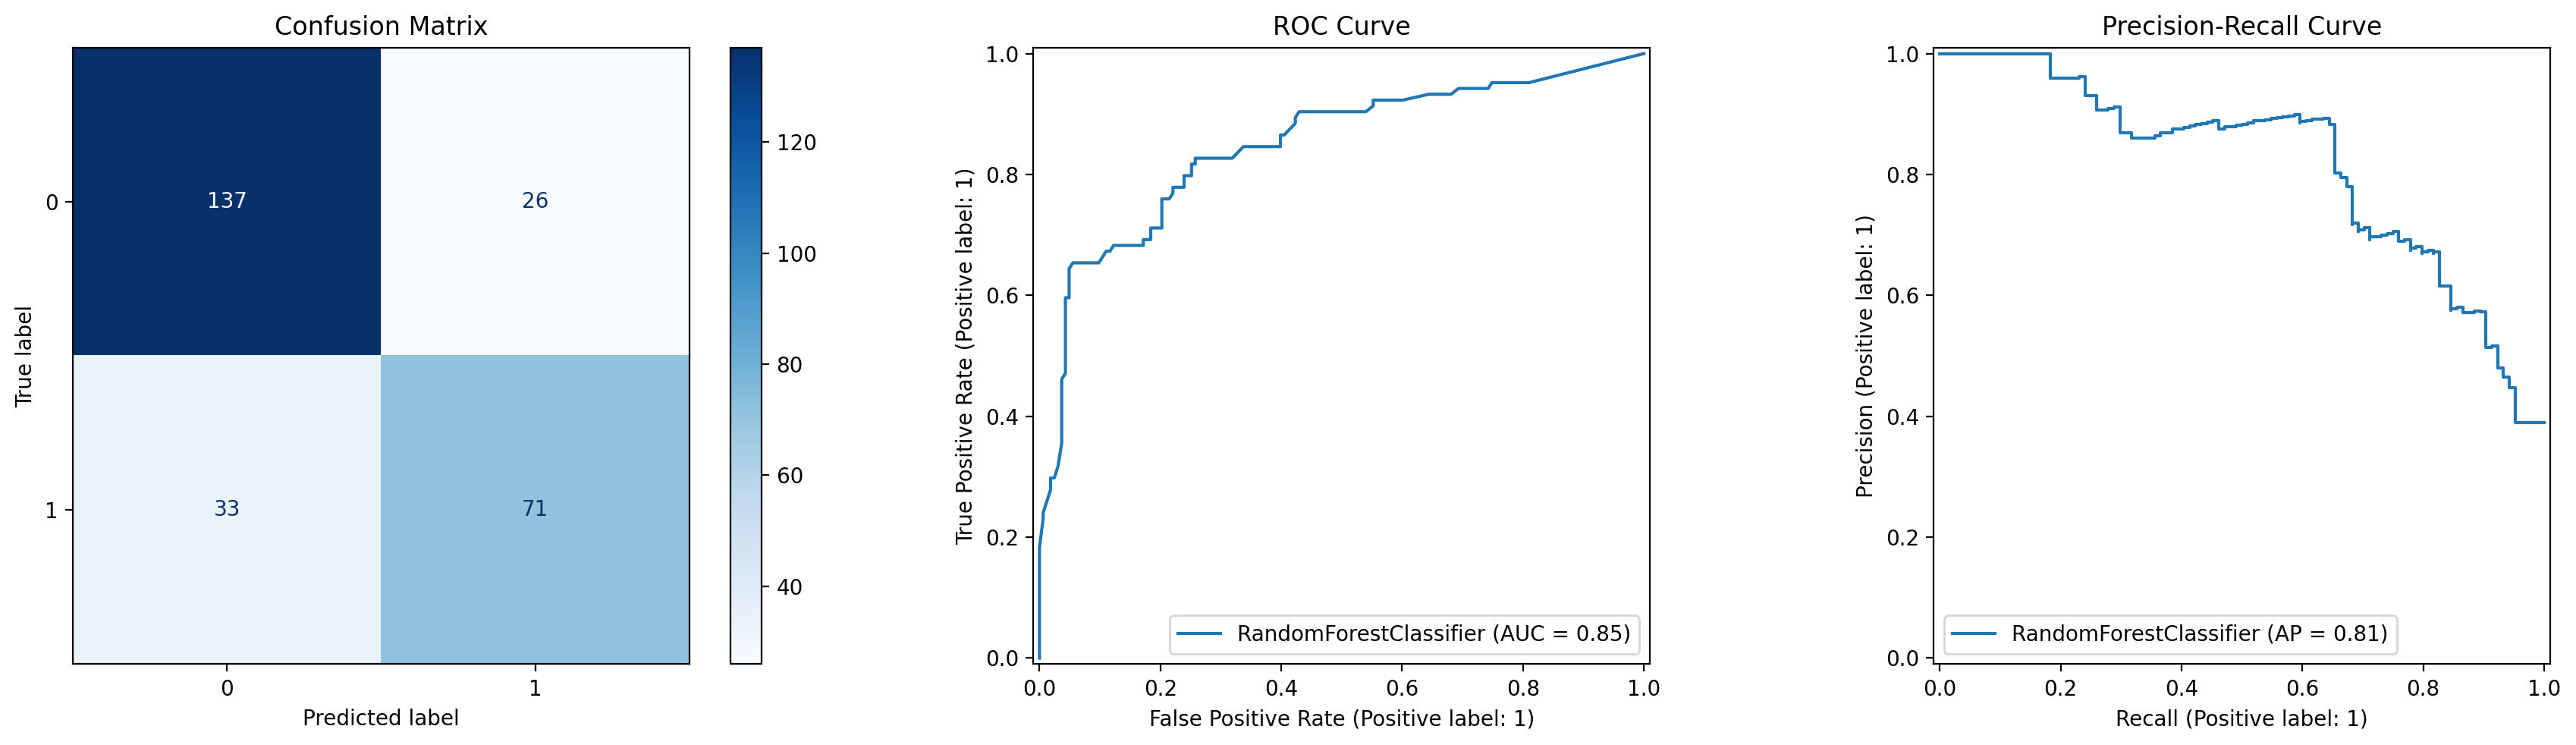

In [49]:
plot_metrics(forest_model, X_test, y_test)

In [50]:
estimator = forest_model.estimators_[0]

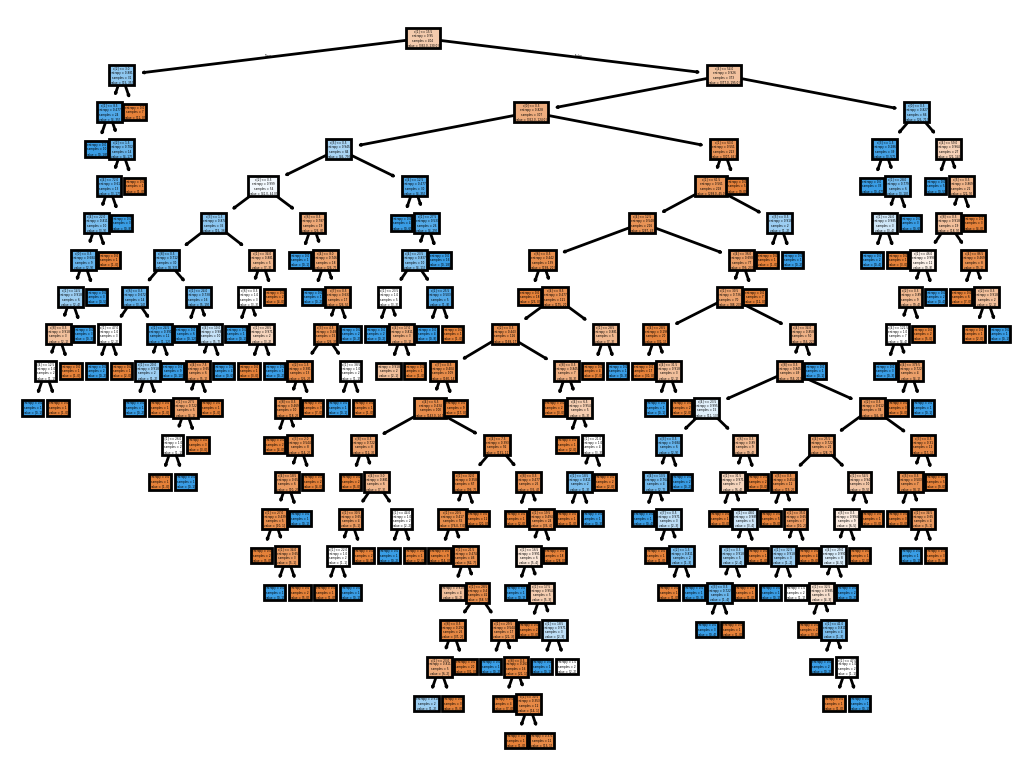

In [51]:
plot_tree(estimator, filled = True);

In [52]:
forestmodel = RandomForestClassifier(criterion = 'entropy')
forestmodel.fit(X, y)
predict = forestmodel.predict(test)

In [53]:
submission = pd.DataFrame({
    'PassengerId': test.index,
    'Survived': predict
})

submission.to_csv('/Users/konansul/Desktop/github/ml-projects/Titanic - Machine Learning from Disaster/submission_forest.csv', index=False)

In [54]:
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,1
4,896,1
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [55]:
predict

array([0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [62]:
def plot_poly_with_metrics(degree):
    model = AdaBoostClassifier(n_estimators=degree)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues', ax=axes[0])
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[1])
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[2])

    axes[0].set_title("Confusion Matrix")
    axes[1].set_title("ROC Curve")
    axes[2].set_title("Precision-Recall Curve")
    plt.tight_layout()
    plt.show()

    print(classification_report(y_test, preds))
    
interact(plot_poly_with_metrics, degree=(1, 100))

interactive(children=(IntSlider(value=50, description='degree', min=1), Output()), _dom_classes=('widget-inter…

<function __main__.plot_poly_with_metrics(degree)>

In [64]:
test = pd.read_csv('/Users/konansul/Downloads/titanic/test.csv')

In [76]:
ada_model = AdaBoostClassifier(n_estimators = 200)
ada_model.fit(X, y)
predict = ada_model.predict(test)

In [77]:
predict

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [78]:
submission = pd.DataFrame({
    'PassengerId': test.index,
    'Survived': predict
})

submission.to_csv('/Users/konansul/Desktop/github/ml-projects/Titanic - Machine Learning from Disaster/ada_submission.csv', index=False)

In [79]:
test

,Sex,Age,SibSp,Parch,Fare,Pclass_second,Pclass_third,Embarked_Q,Embarked_S
PassengerId,,,,,,,,,
892,1,34,0,0,7,0,1,1,0
893,0,47,1,0,7,0,1,0,1
894,1,62,0,0,9,1,0,1,0
895,1,27,0,0,8,0,1,0,1
896,0,22,1,1,12,0,1,0,1
...,...,...,...,...,...,...,...,...,...
1305,1,30,0,0,8,0,1,0,1
1306,0,39,0,0,108,0,0,0,0
1307,1,38,0,0,7,0,1,0,1


In [82]:
test[test['Sex'] == 0].index

Index([ 893,  896,  898,  900,  904,  906,  907,  910,  911,  914,
       ...
       1287, 1289, 1292, 1294, 1300, 1301, 1302, 1303, 1304, 1306],
      dtype='int64', name='PassengerId', length=152)

In [83]:
test1 = test

In [85]:
test1['Survived'] = predict

test1.loc[test['Sex'] == 0, 'Survived'] = 1

submission = pd.DataFrame({
    'PassengerId': test1.index,
    'Survived': test1['Survived']
})

submission.to_csv('/Users/konansul/Desktop/github/ml-projects/Titanic - Machine Learning from Disaster/ada_submission.csv', index=False)